- importando as bibliotecas 

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
sns.set(style="whitegrid")

In [46]:
conn = sqlite3.connect("data/database.sqlite")

In [47]:

dados = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)



In [48]:

matches = pd.read_sql("SELECT * FROM Match;", conn)

matches.shape
matches.head()


,id,country_id,league_id,season,stage,date,match_api_id,home_team_api_id,away_team_api_id,home_team_goal,...,SJA,VCH,VCD,VCA,GBH,GBD,GBA,BSH,BSD,BSA
0,1,1,1,2008/2009,1,2008-08-17 00:00:00,492473,9987,9993,1,...,4.00,1.65,3.40,4.50,1.78,3.25,4.00,1.73,3.40,4.20
1,2,1,1,2008/2009,1,2008-08-16 00:00:00,492474,10000,9994,0,...,3.80,2.00,3.25,3.25,1.85,3.25,3.75,1.91,3.25,3.60
2,3,1,1,2008/2009,1,2008-08-16 00:00:00,492475,9984,8635,0,...,2.50,2.35,3.25,2.65,2.50,3.20,2.50,2.30,3.20,2.75
3,4,1,1,2008/2009,1,2008-08-17 00:00:00,492476,9991,9998,5,...,7.50,1.45,3.75,6.50,1.50,3.75,5.50,1.44,3.75,6.50
4,5,1,1,2008/2009,1,2008-08-16 00:00:00,492477,7947,9985,1,...,1.73,4.50,3.40,1.65,4.50,3.50,1.65,4.75,3.30,1.67


- Entendendo a estrutura da tabela Match

In [49]:
matches.columns

Index(['id', 'country_id', 'league_id', 'season', 'stage', 'date',
       'match_api_id', 'home_team_api_id', 'away_team_api_id',
       'home_team_goal',
       ...
       'SJA', 'VCH', 'VCD', 'VCA', 'GBH', 'GBD', 'GBA', 'BSH', 'BSD', 'BSA'],
      dtype='str', length=115)

In [50]:
# Subconjunto de colunas para análise das partidas
partidas_eda = matches[
    [
        "season",
        "date",
        "home_team_api_id",
        "away_team_api_id",
        "home_team_goal",
        "away_team_goal"
    ]
].copy()

partidas_eda


,season,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal
0,2008/2009,2008-08-17 00:00:00,9987,9993,1,1
1,2008/2009,2008-08-16 00:00:00,10000,9994,0,0
2,2008/2009,2008-08-16 00:00:00,9984,8635,0,3
3,2008/2009,2008-08-17 00:00:00,9991,9998,5,0
4,2008/2009,2008-08-16 00:00:00,7947,9985,1,3
...,...,...,...,...,...,...
25974,2015/2016,2015-09-22 00:00:00,10190,10191,1,0
25975,2015/2016,2015-09-23 00:00:00,9824,10199,1,2
25976,2015/2016,2015-09-23 00:00:00,9956,10179,2,0
25977,2015/2016,2015-09-22 00:00:00,7896,10243,0,0


In [51]:
# conferindo valores unicos
partidas_eda.info()

<class 'pandas.DataFrame'>
RangeIndex: 25979 entries, 0 to 25978
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   season            25979 non-null  str  
 1   date              25979 non-null  str  
 2   home_team_api_id  25979 non-null  int64
 3   away_team_api_id  25979 non-null  int64
 4   home_team_goal    25979 non-null  int64
 5   away_team_goal    25979 non-null  int64
dtypes: int64(4), str(2)
memory usage: 1.2 MB


In [52]:
#Converter a coluna de data
partidas_eda['date'] = pd.to_datetime(partidas_eda['date'])
partidas_eda["ano"] = partidas_eda["date"].dt.year

- Gols totais das partidas

In [53]:
partidas_eda['gols_totais'] = (
    partidas_eda['home_team_goal'] +
    partidas_eda['away_team_goal']
)


Resultado das partidas

In [54]:
def resultado_partida(linha):
    if linha['home_team_goal'] > linha['away_team_goal']:
        return 'Vitoria mandante'
    elif linha['home_team_goal'] < linha['away_team_goal']:
        return 'Vitoria visitante'
    else:
        return 'Empate'
    

partidas_eda["resultado"] = partidas_eda.apply(
    resultado_partida, axis=1
)


In [55]:
partidas_eda.head()

,season,date,home_team_api_id,away_team_api_id,home_team_goal,away_team_goal,ano,gols_totais,resultado
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante


Distribuindo gols por partidas

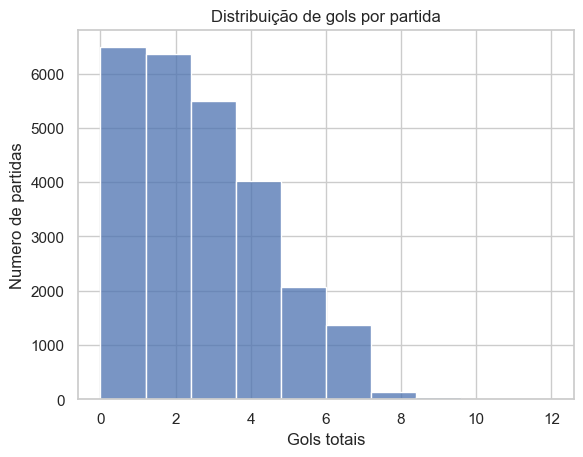

In [56]:
sns.histplot(partidas_eda['gols_totais'], bins=10)
plt.title('Distribuição de gols por partida')
plt.xlabel('Gols totais')
plt.ylabel('Numero de partidas')
plt.show()

Distribuindo Resultados

In [57]:
partidas_eda['resultado'].value_counts(normalize= True)

resultado
Vitoria mandante     0.458717
Vitoria visitante    0.287386
Empate               0.253897
Name: proportion, dtype: float64

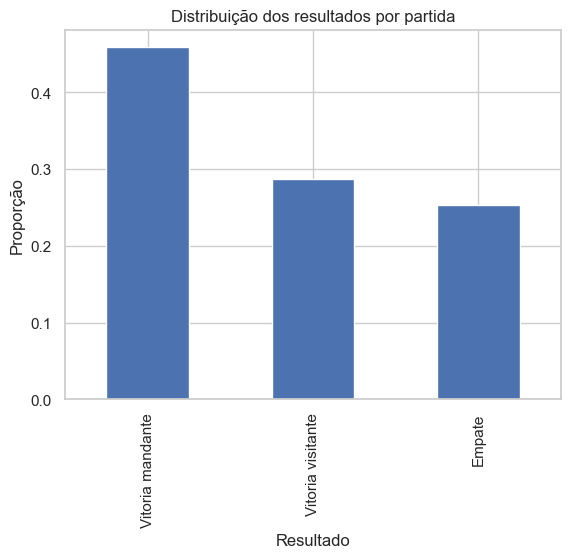

In [58]:
partidas_eda['resultado'].value_counts(
    normalize= True).plot(kind='bar')

plt.title('Distribuição dos resultados por partida')
plt.ylabel('Proporção')
plt.xlabel('Resultado')
plt.show()


In [59]:

partidas_eda = partidas_eda.rename(columns={
    "home_team_goal": "gols_mandante",
    "away_team_goal": "gols_visitante"
})


Mandante x Visitante gols

In [60]:
# Vendo quantos gols cada lado fez
partidas_eda[['gols_mandante', 'gols_visitante']].describe()

,gols_mandante,gols_visitante
count,25979.000000,25979.000000
mean,1.544594,1.160938
std,1.297158,1.142110
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,1.000000
75%,2.000000,2.000000
max,10.000000,9.000000


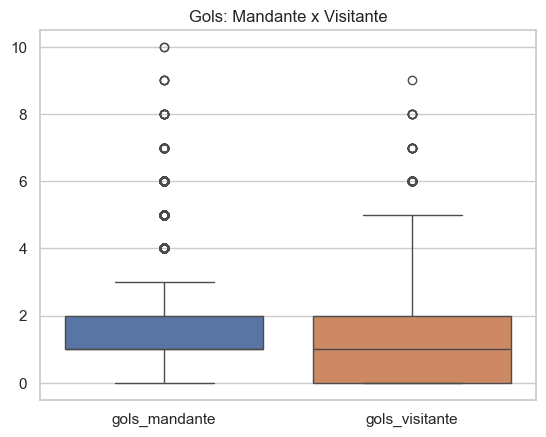

In [61]:
# comparando
sns.boxplot(
    data=partidas_eda[['gols_mandante', 'gols_visitante']]
)
plt.title('Gols: Mandante x Visitante')
plt.show()

Analise temporal

In [62]:
# media de gols por temporada
media_gols_temporada = (
    partidas_eda.groupby('season')['gols_totais'].mean()
)
media_gols_temporada

season
2008/2009    2.607336
2009/2010    2.672446
2010/2011    2.683742
2011/2012    2.716460
2012/2013    2.772699
2013/2014    2.766821
2014/2015    2.675789
2015/2016    2.754660
Name: gols_totais, dtype: float64

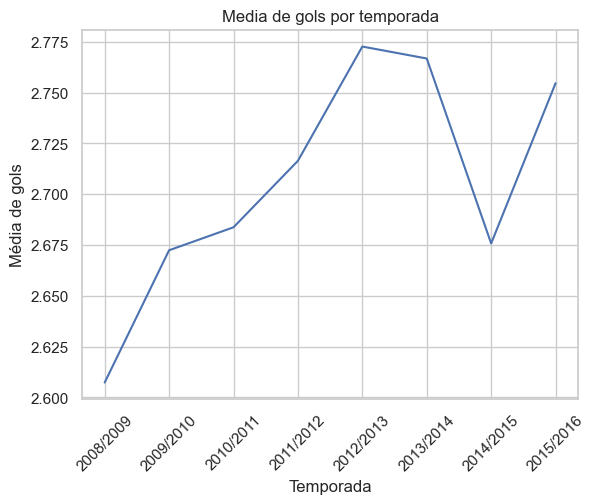

In [63]:
sns.lineplot(
    x=media_gols_temporada.index,
    y=media_gols_temporada.values
)
plt.title('Media de gols por temporada')
plt.xlabel('Temporada')
plt.ylabel('Média de gols')
plt.xticks(rotation=45)
plt.show()

Tabela de times

In [64]:
times = pd.read_sql("SELECT team_api_id, team_long_name FROM Team;",
                    conn)
times.head

<bound method NDFrame.head of      team_api_id      team_long_name
0           9987            KRC Genk
1           9993        Beerschot AC
2          10000    SV Zulte-Waregem
3           9994    Sporting Lokeren
4           9984   KSV Cercle Brugge
..           ...                 ...
294        10190       FC St. Gallen
295        10191             FC Thun
296         9777         Servette FC
297         7730  FC Lausanne-Sports
298         7896              Lugano

[299 rows x 2 columns]>

Mandante

In [65]:
partidas_times = partidas_eda.merge(
    times,
    left_on='home_team_api_id',
    right_on='team_api_id',
    how='left'
)

partidas_times = partidas_times.rename(columns={
    "team_long_name": "time_mandante"
})

partidas_times.head()

,season,date,home_team_api_id,away_team_api_id,gols_mandante,gols_visitante,ano,gols_totais,resultado,team_api_id,time_mandante
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate,9987,KRC Genk
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate,10000,SV Zulte-Waregem
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante,9984,KSV Cercle Brugge
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante,9991,KAA Gent
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante,7947,FCV Dender EH


Visitante

In [66]:

partidas_times = partidas_times.merge(
    times,
    left_on="away_team_api_id",
    right_on="team_api_id",
    how="left"
)

partidas_times = partidas_times.rename(columns={
    "team_long_name": "time_visitante"
})
partidas_times.head()

,season,date,home_team_api_id,away_team_api_id,gols_mandante,gols_visitante,ano,gols_totais,resultado,team_api_id_x,time_mandante,team_api_id_y,time_visitante
0,2008/2009,2008-08-17,9987,9993,1,1,2008,2,Empate,9987,KRC Genk,9993,Beerschot AC
1,2008/2009,2008-08-16,10000,9994,0,0,2008,0,Empate,10000,SV Zulte-Waregem,9994,Sporting Lokeren
2,2008/2009,2008-08-16,9984,8635,0,3,2008,3,Vitoria visitante,9984,KSV Cercle Brugge,8635,RSC Anderlecht
3,2008/2009,2008-08-17,9991,9998,5,0,2008,5,Vitoria mandante,9991,KAA Gent,9998,RAEC Mons
4,2008/2009,2008-08-16,7947,9985,1,3,2008,4,Vitoria visitante,7947,FCV Dender EH,9985,Standard de Liège


Gols marcados como mandante 

In [67]:
gols_mandante = (
    partidas_times.groupby('time_mandante')['gols_mandante'].sum().sort_values(ascending= False)
)
gols_mandante.head(10)

time_mandante
Real Madrid CF       505
FC Barcelona         495
Celtic               389
FC Bayern Munich     382
PSV                  370
Manchester City      365
Ajax                 360
FC Basel             344
Manchester United    338
Chelsea              333
Name: gols_mandante, dtype: int64

Gols sofridos como mandante

In [68]:
gols_sofridos_mandante = (partidas_times.groupby('time_mandante')['gols_visitante'].sum().sort_values()
)
gols_sofridos_mandante.head(10)

time_mandante
Amadora                         15
Angers SCO                      15
Uniao da Madeira                17
UD Las Palmas                   17
FC Ingolstadt 04                18
Watford                         19
Feirense                        19
Termalica Bruk-Bet Nieciecza    19
Middlesbrough                   20
Trofense                        21
Name: gols_visitante, dtype: int64

Saldo de gols como Mandante

In [69]:
ranking_mandante = (
    partidas_times.groupby('time_mandante')[['gols_mandante', 'gols_visitante']].sum())

ranking_mandante['saldo_gols_mandante'] = (
    ranking_mandante['gols_mandante'] - ranking_mandante['gols_visitante']
)

ranking_mandante.sort_values('saldo_gols_mandante', ascending=False).head()

,gols_mandante,gols_visitante,saldo_gols_mandante
time_mandante,,,
FC Barcelona,495,101,394
Real Madrid CF,505,147,358
Celtic,389,88,301
FC Bayern Munich,382,96,286
Ajax,360,78,282



### Conclusão Parcial

Nesta etapa foi realizada a análise exploratória inicial da base de dados,
com foco nas partidas e no desempenho dos times atuando como mandantes.
Foram identificados padrões de distribuição de gols, vantagem do mandante
e diferenças claras entre desempenho ofensivo e defensivo dos times.

